# Konwolucyjne sieci neuronowe

Głębokie sieci konwolucyjne (CNN) dziłają na zasadzie filtracji stopniowo różnych części danych uczących i wyostrzają
ważne cechy w procesie dyskryminacji z wykorzystywanym do klasyfikacji wzorców. Konwolucje pozwalają ekstrahować proste cechy w początkowych warstwach sieci, a następnie w kolejnych.

Jest
przeznaczona głównie do obliczeń na strukturach 2D, ale sieci konwolucyjne mogą również porządkować
jednostki obliczeniowe w 3D, gdzie wyznacznikami są szerokość, wysokość i głębokość

Naszą prezentacje zaczniemy od importowania bibliotek które będziemy używać:


*   Tensowflow w którym jest Keras do nauczania maszynowego
*   Pandas do wczytywania plików postaci CSV
*   Matplotlib do tworzenia wykresów
*   opendatasets do wczytywania datesetów z strony Kaggle




In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers, utils, regularizers, callbacks
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2024-06-05 12:55:01.992274: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-06-05 12:55:01.992394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-06-05 12:55:02.119798: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Wczytajmy dataset z obrazami Motyli:

In [2]:
Dataset = pd.read_csv("/kaggle/input/butterfly-images40-species/butterflies and moths.csv")

Sprawdźmy jak nasz dataset wygląda:

In [ ]:
Dataset

Dodajmy ścieżke do naszego datasetu dla ułatwienia pracy nad nim

In [3]:
Dataset["filepaths"] ="/kaggle/input/butterfly-images40-species/"+ Dataset["filepaths"]
Dataset

,class id,filepaths,labels,data set
0,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
1,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
2,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
3,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
4,0,/kaggle/input/butterfly-images40-species/train...,ADONIS,train
...,...,...,...,...
13589,99,/kaggle/input/butterfly-images40-species/valid...,ZEBRA LONG WING,valid
13590,99,/kaggle/input/butterfly-images40-species/valid...,ZEBRA LONG WING,valid
13591,99,/kaggle/input/butterfly-images40-species/valid...,ZEBRA LONG WING,valid
13592,99,/kaggle/input/butterfly-images40-species/valid...,ZEBRA LONG WING,valid


Sprawdźmy ile unikalnych klas jest w naszym datasecie i ich poszczególne nazwy

In [4]:
butterfly_classes = Dataset['labels'].unique()
butterfly_classes_num = Dataset['labels'].nunique()
print("Unikalne nazwy poszczególnych klas to:",butterfly_classes, "a ilość unikalnych klas wynosi: ", butterfly_classes_num)

Unikalne nazwy poszczególnych klas to: ['ADONIS' 'AFRICAN GIANT SWALLOWTAIL' 'AMERICAN SNOOT' 'AN 88' 'APPOLLO'
 'ARCIGERA FLOWER MOTH' 'ATALA' 'ATLAS MOTH' 'BANDED ORANGE HELICONIAN'
 'BANDED PEACOCK' 'BANDED TIGER MOTH' 'BECKERS WHITE'
 'BIRD CHERRY ERMINE MOTH' 'BLACK HAIRSTREAK' 'BLUE MORPHO'
 'BLUE SPOTTED CROW' 'BROOKES BIRDWING' 'BROWN ARGUS' 'BROWN SIPROETA'
 'CABBAGE WHITE' 'CAIRNS BIRDWING' 'CHALK HILL BLUE' 'CHECQUERED SKIPPER'
 'CHESTNUT' 'CINNABAR MOTH' 'CLEARWING MOTH' 'CLEOPATRA'
 'CLODIUS PARNASSIAN' 'CLOUDED SULPHUR' 'COMET MOTH' 'COMMON BANDED AWL'
 'COMMON WOOD-NYMPH' 'COPPER TAIL' 'CRECENT' 'CRIMSON PATCH'
 'DANAID EGGFLY' 'EASTERN COMA' 'EASTERN DAPPLE WHITE'
 'EASTERN PINE ELFIN' 'ELBOWED PIERROT' 'EMPEROR GUM MOTH'
 'GARDEN TIGER MOTH' 'GIANT LEOPARD MOTH' 'GLITTERING SAPPHIRE'
 'GOLD BANDED' 'GREAT EGGFLY' 'GREAT JAY' 'GREEN CELLED CATTLEHEART'
 'GREEN HAIRSTREAK' 'GREY HAIRSTREAK' 'HERCULES MOTH'
 'HUMMING BIRD HAWK MOTH' 'INDRA SWALLOW' 'IO MOTH' 'Iphiclus sis

# Preprocessing
Stwórzmy funkcja która będzie augmentować nasz dataset, a następnie wyciągnie nasze zdjęcia z folderu korzystając z pliku CSV.
Augmentacja będzie polegała na:

1.  Przeskalowaniu poszczególnych pikseli dla ułatwienia w nauczaniu maszynowym
2.  rotacji do 40 stopni
3.  przeskalowaniu w szerokości i wysokości
4.  przytnięciu
5.  odbiciu w poziomie





In [5]:
def prep_data(train_data, validation_data, test_data, batch_size=32, augment = True):
    IMAGE_SIZE = (224,224)
    if augment:
        train_datagen = ImageDataGenerator(
              rescale=1./255,
              rotation_range=40,
              width_shift_range=0.2,
              height_shift_range=0.2,
              shear_range=0.2,
              zoom_range=0.2,
              horizontal_flip=True)

        validation_datagen = ImageDataGenerator(rescale=1./255)
    else:
        train_datagen = ImageDataGenerator(rescale=1./255)
        validation_datagen = ImageDataGenerator(rescale=1./255)
    
    train_set = train_datagen.flow_from_dataframe(
        dataframe=train_data,
        x_col='filepaths',
        y_col='labels',
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        seed = 10,
        class_mode='sparse')

    validation_set = validation_datagen.flow_from_dataframe(
        dataframe=validation_data,
        x_col='filepaths',
        y_col='labels',
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        seed = 10,
        class_mode='sparse')
    
    test_set = validation_datagen.flow_from_dataframe(
        dataframe=test_data,
        x_col='filepaths',
        y_col='labels',
        target_size=IMAGE_SIZE,
        batch_size=batch_size,
        seed = 10,
        class_mode='sparse')

    return train_set, validation_set, test_set

A tu jest funkcja która będzie tworzyła wykres po wyuczeniu modelu

In [6]:
def plotuj(model):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(model.history['accuracy'], label='accuracy')
    ax[0].plot(model.history['val_accuracy'], label = 'val_accuracy')
    ax[0].set_title("Treningowy i walidacyjny zbior - dokladnosc")
    ax[1].plot(model.history['loss'], label='loss')
    ax[1].plot(model.history['val_loss'], label = 'val_loss')
    ax[1].set_title("Treningowy i walidacyjny zbior - funkcja straty")
    ax[0].legend(loc='lower right')
    ax[1].legend(loc='lower right')
    ax[0].set_xlabel("epokq")
    ax[1].set_xlabel("epoka")
    plt.tight_layout()
    plt.show()

Ustalmy nasz set treningowy, walidacyjny i testowy

In [7]:
train_data = Dataset.loc[Dataset["data set"] == "train"]
validation_data = Dataset.loc[Dataset["data set"] == "valid"]
test_data = Dataset.loc[Dataset["data set"] == "test"]
print("Rozmiar setu treningowego: ",len(train_data)," walidacyjnego: ",len(validation_data),"testowego: ",len(test_data))

Rozmiar setu treningowego:  12594  walidacyjnego:  500 testowego:  500


Sprawdzmy jak wyglądają nasze obrazki, bez augmentowania:

In [ ]:
train_set, validation_set, test_set = prep_data(train_data, validation_data, test_data,  augment = False)

# Podgląd w dane
Jak widzimy mamy 12594 obrazków w treningowym zbiorze i 500 obrazków w Walidacyjnym zbiorze

In [ ]:
image, label = next(train_set)

class_names = train_set.class_indices
class_names = {v: k for k, v in class_names.items()}

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(12):
    axes[i//6][i%6].imshow(image[i])
    label_index = int(label[i])
    class_name = class_names[label_index]
    axes[i//6][i%6].set_title(f"{class_name}")
    axes[i//6][i%6].axis('off')

plt.tight_layout()
plt.show()

A teraz go augmentujmy

In [8]:
train_set, validation_set, test_set = prep_data(train_data, validation_data, test_data)

Found 12594 validated image filenames belonging to 100 classes.
Found 500 validated image filenames belonging to 100 classes.
Found 500 validated image filenames belonging to 100 classes.


Spójrzmy na obrazy jeszcze raz, już po augmentacji:

In [ ]:
image, label = next(train_set)
class_names = train_set.class_indices
class_names = {v: k for k, v in class_names.items()}
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(12):
    axes[i//6][i%6].imshow(image[i])
    label_index = int(label[i])
    class_name = class_names[label_index]
    axes[i//6][i%6].set_title(f"{class_name}")
    axes[i//6][i%6].axis('off')

plt.tight_layout()
plt.show()

# Pierwszy model
Nieźle, jak widzimy nasz zestaw treningowy jest augmentowany.
Stwórzmy pierwszy model dla naszego nauczania maszynowego

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(filters=32,kernel_size=(3,3), activation='relu', input_shape = (224,224,3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(100 , activation='softmax'))

model.summary()

Teraz uruchomimy nasz model:

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(0.0005), 
    metrics=['accuracy']
)
model1_1 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback]
    )

In [ ]:
plotuj(model1_1)

In [ ]:
model.evaluate(test_set)

# Drugi model
Stwórzmy nowy model, bardziej rozbudowany

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(filters=32,kernel_size=(3,3), activation='relu', input_shape = (224,224,3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(516, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(100, activation='softmax'))

model.summary()


In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
model1_2 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback])

In [ ]:
plotuj(model1_2)

In [ ]:
model.evaluate(test_set)

# Trzeci Model

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2,2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2,2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D(pool_size=(2,2)))
model.add(layers.Dropout(0.25))

model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.25))

model.add(layers.Dense(100, activation='softmax'))

model.summary()

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
model1_3 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback])

In [ ]:
plotuj(model1_3)

In [ ]:
model.evaluate(test_set)

# Czwarty model

In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(256, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(100 , activation='softmax'))

model.summary()

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

model1_4 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback])

In [ ]:
plotuj(model1_4)

In [ ]:
model.evaluate(test_set)

# Piaty model

In [ ]:
model = models.Sequential()
    
model.add(layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.BatchNormalization(axis=-1))

model.add(layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(layers.Conv2D(filters=128, kernel_size=(3,3), activation='relu'))
model.add(layers.MaxPool2D(pool_size=(2, 2)))
model.add(layers.BatchNormalization(axis=-1))

model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))

model.add(layers.Dense(100, activation='softmax'))
model.summary()

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(optimizer=tf.keras.optimizers.RMSprop(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
model1_5 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback])

In [ ]:
plotuj(model1_5)

In [ ]:
model.evaluate(test_set)

# Inception V3

Teraz użyjemy dostępny w Kerasie, gotowy model do nauczania konwolucyjnego, zwany InceptionV3. 

Na obrazie poniżej, jest wgląd w jego budowę
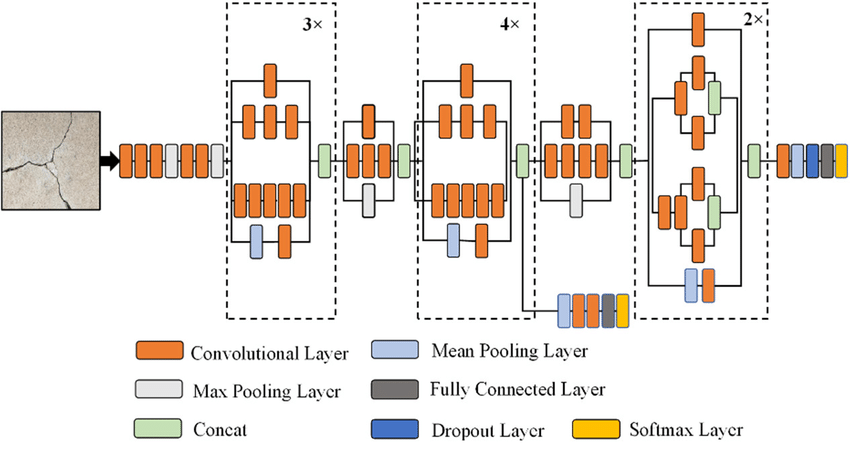

Zacznijmy od importowania tego modelu

In [20]:
from tensorflow.keras.applications import InceptionV3
base_model = InceptionV3(
    include_top=False,
    input_shape=(224, 224, 3)

    
)

Ponieważ InceptionV3 odpowiada tylko za część konwolucyjną, to osobno musimy dodać warstwę pełnie połączoną

In [29]:
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(100, activation='softmax'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 21,768,352 (83.04 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [30]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(0.0005), 
    metrics=['accuracy']
)

In [31]:
fine_tune_inception1_1 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback]
    )

Epoch 1/50


W0000 00:00:1717604436.558831      88 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


155/394 ━━━━━━━━━━━━━━━━━━━━ 2:08 539ms/step - accuracy: 0.1807 - loss: 3.8624

W0000 00:00:1717604519.659992      86 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.3574 - loss: 2.8781

W0000 00:00:1717604608.198591      88 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


394/394 ━━━━━━━━━━━━━━━━━━━━ 237s 447ms/step - accuracy: 0.3579 - loss: 2.8755 - val_accuracy: 0.8500 - val_loss: 0.6760
Epoch 2/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 140s 350ms/step - accuracy: 0.7559 - loss: 0.8917 - val_accuracy: 0.8320 - val_loss: 7.1192
Epoch 3/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 142s 353ms/step - accuracy: 0.7829 - loss: 0.8153 - val_accuracy: 0.8280 - val_loss: 0.8571
Epoch 4/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 141s 352ms/step - accuracy: 0.8217 - loss: 0.6665 - val_accuracy: 0.8480 - val_loss: 4.2215
Epoch 5/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 145s 360ms/step - accuracy: 0.8206 - loss: 0.6471 - val_accuracy: 0.8140 - val_loss: 25.9010
Epoch 6/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 141s 350ms/step - accuracy: 0.8332 - loss: 0.5975 - val_accuracy: 0.8940 - val_loss: 2.2165
Epoch 7/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 140s 347ms/step - accuracy: 0.8507 - loss: 0.5495 - val_accuracy: 0.8440 - val_loss: 1.0916
Epoch 8/50
394/394 ━━━━━━━━━━━━━━━━━━━━ 141s 351ms/step - accuracy: 0.8443 - loss: 0.5

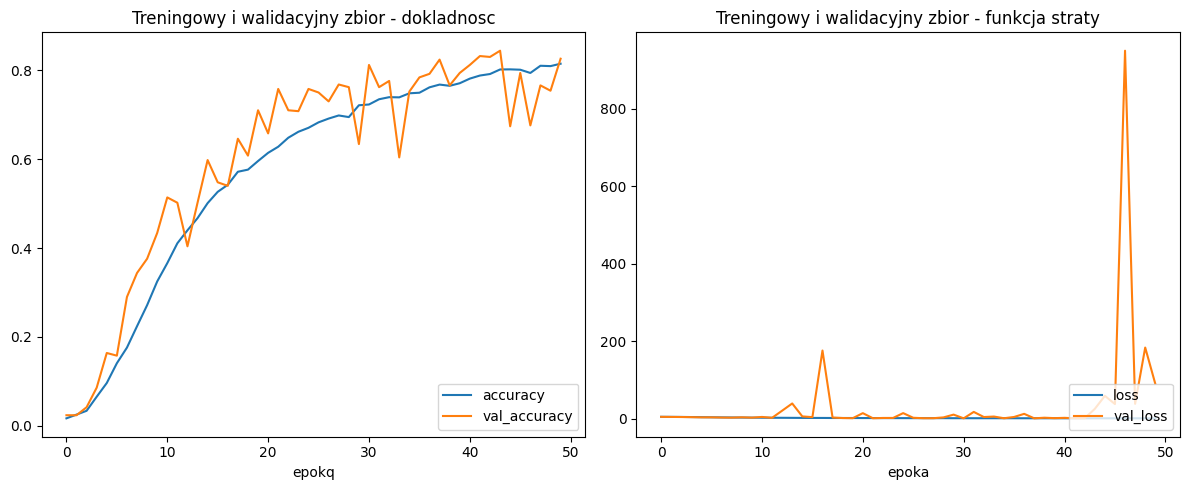

In [27]:
plotuj(fine_tune_inception1_1)

In [28]:
model.evaluate(test_set)

 1/16 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.9062 - loss: 0.4585

/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 212ms/step - accuracy: 0.8681 - loss: 52.7699


[52.3263053894043, 0.8700000047683716]

Zauważmy, że dokładność w tym modelu jest bardzo wysoka. Zobaczmy kilka przykładów jak radzi on sobie na zbiorze testowym

In [ ]:
image, temp = next(test_set)
for i in range(10):
    prediction = model.predict(image)
    print("Gatunek prawdziwy: ", class_names[int(temp[i])])
    print("Gatunek przewidywany: ", class_names [prediction[i].argmax()])
    plt.imshow(image[i])
    plt.show()

In [ ]:
model.evaluate(test_set)

# Inception V3 rozbudowany
Kolejny model 

In [ ]:
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(100, activation='softmax'))
model.summary()

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.0005), 
    metrics=['accuracy']
)
fine_tune_inception1_2 = model.fit(
    train_set,
    epochs=30,
    validation_data=validation_set,
    callbacks = [callback]
    )

In [ ]:
plotuj(fine_tune_inception1_2)

In [ ]:
model.evaluate(test_set)

# InceptionV3 zbudowana wersja

Spróbujmy stworzyć nasz własny InceptionV3 używając dokumentacji 

In [ ]:
from keras.models import Model
from keras.layers import concatenate
from keras.layers import Conv2D , MaxPooling2D , Input , GlobalAveragePooling2D ,AveragePooling2D, Dense , Dropout ,Activation, Flatten , BatchNormalization


def Conv2D_z_Batch_Normalisation(prev_layer , filters , kernel_size , strides =(1,1) , padding = 'same'):
    x = Conv2D(filters=filters, kernel_size = kernel_size, strides=strides , padding=padding, use_bias = False)(prev_layer)
    x = BatchNormalization(axis=3, scale = False)(x)
    x = Activation(activation='relu')(x)
    return x

def StemBlock(prev_layer):
    x = Conv2D_z_Batch_Normalisation(prev_layer,filters= 32, kernel_size = (3,3) , strides=(2,2), padding = 'valid')
    x = Conv2D_z_Batch_Normalisation(x, 32, (3,3), padding="valid")
    x = Conv2D_z_Batch_Normalisation(x, 64, kernel_size=(3,3))
    x = MaxPooling2D(pool_size=(3,3) , strides=(2,2)) (x)
    
    x = Conv2D_z_Batch_Normalisation(x, 80, (1,1), padding="valid")
    x = Conv2D_z_Batch_Normalisation(x, 192, (3,3), padding="valid")
    x = MaxPooling2D(pool_size=(3,3) , strides=(2,2)) (x)
    
    return x    
    

def InceptionBlock_A(prev_layer  , filters):
    
    branch1x1 = Conv2D_z_Batch_Normalisation(prev_layer, filters = 64, kernel_size=(1,1))

    branch5x5 = Conv2D_z_Batch_Normalisation(prev_layer, 48, (1,1))
    branch5x5 = Conv2D_z_Batch_Normalisation(branch5x5, 64, (5,5)) 
       
    branch3x3 = Conv2D_z_Batch_Normalisation(prev_layer, 64, (1,1))
    branch3x3 = Conv2D_z_Batch_Normalisation(branch3x3, 96, (3,3))
    branch3x3 = Conv2D_z_Batch_Normalisation(branch3x3, 96, (3,3))
    
    branch_pool = AveragePooling2D(pool_size=(3,3) , strides=(1,1) , padding='same') (prev_layer)
    branch_pool = Conv2D_z_Batch_Normalisation(branch_pool, filters, (1,1))
    
    
    output = concatenate([branch1x1 , branch5x5 , branch3x3 , branch_pool], axis=3)
    
    return output



def InceptionBlock_B(prev_layer , filters):
    
    branch1x1= Conv2D_z_Batch_Normalisation(prev_layer, filters = 192, kernel_size = (1,1))

    branch7x7 = Conv2D_z_Batch_Normalisation(prev_layer, filters = filters, kernel_size = (1,1))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, filters = filters, kernel_size = (1,7))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, 192, (7,1))
    
    
    branch7x7_ = Conv2D_z_Batch_Normalisation(prev_layer, filters = filters, kernel_size = (1,1))
    branch7x7_ = Conv2D_z_Batch_Normalisation(branch7x7_, filters = filters, kernel_size = (7,1))
    branch7x7_ = Conv2D_z_Batch_Normalisation(branch7x7_, filters = filters, kernel_size = (1,7))
    branch7x7_ = Conv2D_z_Batch_Normalisation(branch7x7_, filters = filters, kernel_size = (7,1))    
    branch7x7_ = Conv2D_z_Batch_Normalisation(branch7x7_, 192, (1,7))
    
    branch_pool = AveragePooling2D(pool_size=(3,3) , strides=(1,1) , padding ='same') (prev_layer)
    branch_pool = Conv2D_z_Batch_Normalisation(branch_pool, 192, (1,1))
    
    
    output = concatenate([branch1x1 , branch7x7 , branch7x7_ , branch_pool], axis = 3)
    
    return output    


    
def InceptionBlock_C(prev_layer):
    
    branch1x1 = Conv2D_z_Batch_Normalisation(prev_layer, filters = 320, kernel_size = (1,1))

    branch3x3 = Conv2D_z_Batch_Normalisation(prev_layer, 384, (1,1))
    branch3x3_1 = Conv2D_z_Batch_Normalisation(branch3x3, 384, (1,3))
    branch3x3_2 = Conv2D_z_Batch_Normalisation(branch3x3, 384, (3,1))
    branch3x3 = concatenate([branch3x3_1 , branch3x3_2], axis = 3)
    
    branch3x3_ = Conv2D_z_Batch_Normalisation(prev_layer, 448, (1,1))
    branch3x3_ = Conv2D_z_Batch_Normalisation(branch3x3_, 384, (3,3))
    branch3x3_1_ = Conv2D_z_Batch_Normalisation(branch3x3_, 384, (1,3))    
    branch3x3_2_ = Conv2D_z_Batch_Normalisation(branch3x3_, 384, (3,1))
    branch3x3_ = concatenate([branch3x3_1_ , branch3x3_2_], axis = 3)
    
    branch_pool = AveragePooling2D(pool_size=(3,3) , strides=(1,1) , padding='same')(prev_layer)
    branch_pool = Conv2D_z_Batch_Normalisation(branch_pool, 192, (1,1))
        
    output = concatenate([branch1x1 , branch3x3 , branch3x3_ , branch_pool], axis = 3)
    
    return output

def ReductionBlock_A(prev_layer):
    
    branch3x3 = Conv2D_z_Batch_Normalisation(prev_layer, filters = 384, kernel_size=(3,3) , strides=(2,2), padding = 'valid' )

    branch3x3_ = Conv2D_z_Batch_Normalisation(prev_layer, 64, (1,1))
    branch3x3_ = Conv2D_z_Batch_Normalisation(branch3x3_, 96, (3,3))
    branch3x3_ = Conv2D_z_Batch_Normalisation(branch3x3_, 96, (3,3) , strides=(2,2), padding = 'valid' ) \
    
    branch_pool = MaxPooling2D(pool_size=(3,3) , strides=(2,2))(prev_layer)
    
    output = concatenate([branch3x3 , branch3x3_ , branch_pool], axis = 3)
    
    return output

    

def ReductionBlock_B(prev_layer):
    
    branch3x3 = Conv2D_z_Batch_Normalisation(prev_layer, filters = 192, kernel_size = (1,1) )
    branch3x3 = Conv2D_z_Batch_Normalisation(branch3x3, 320, (3,3) , strides=(2,2) , padding='valid' )

    branch7x7 = Conv2D_z_Batch_Normalisation(prev_layer, 192, (1,1))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, 192, (1,7))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, 192, (7,1))
    branch7x7 = Conv2D_z_Batch_Normalisation(branch7x7, 192, (3,3) , strides=(2,2) , padding = 'valid')
    
    branch_pool = MaxPooling2D(pool_size=(3,3) , strides=(2,2) )(prev_layer)
    
    output = concatenate([branch3x3 , branch7x7 , branch_pool], axis = 3)
    
    return output


def InceptionV3(input_shape):
    
    input_layer = Input(shape=input_shape)

    x = StemBlock(input_layer)
    
    x = InceptionBlock_A(prev_layer = x ,filters = 32)
    x = InceptionBlock_A(prev_layer = x , filters =64)
    x = InceptionBlock_A(prev_layer = x ,filters = 64)
    
    x = ReductionBlock_A(prev_layer = x )
    
    x = InceptionBlock_B(prev_layer = x , filters = 128)
    x = InceptionBlock_B(prev_layer = x , filters = 160)
    x = InceptionBlock_B(prev_layer = x , filters = 160)
    x = InceptionBlock_B(prev_layer = x , filters = 192)

    x = ReductionBlock_B(prev_layer = x)
    
    x = InceptionBlock_C(prev_layer = x)
    x = InceptionBlock_C(prev_layer = x)
    
    #x = GlobalAveragePooling2D()(x)
    model = Model(input_layer, x, name = 'Inception-V3')
    
    return model

In [ ]:
base_model = InceptionV3((224,224,3))

In [ ]:
model = models.Sequential()
model.add(base_model)
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(100, activation='softmax'))
model.summary()

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.00005), 
    metrics=['accuracy']
)

In [ ]:
fine_tune_inception1_3 = model.fit(
    train_set,
    epochs=50,
    validation_data=validation_set,
    callbacks = [callback]
    )

In [ ]:
plotuj(fine_tune_inception1_3)

In [ ]:
model.evaluate(test_set)